<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Установка библиотек**

In [59]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-9yl2yuml
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-9yl2yuml
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
Работает на устройстве: cpu


# **Обучение KAN**

MultKAN

In [60]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:

      for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
        for v0 in [0.0, 0.5, 1.0]:

          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 10, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

          for i in range(len(x)):
            all_data.append([c, v[i], k, x[i], m, a_clean[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # (x, v, k, c, m)
y = all_data[:, 5]    # a

# Разбиение на train/test (исходное)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование только x и v (обучаем scaler на трейне, применяем ко всем)
from sklearn.preprocessing import StandardScaler
scaler_dyn = StandardScaler()
scaler_dyn.fit(X_train[:, :2])
X_train[:, :2] = scaler_dyn.transform(X_train[:, :2])
X_test[:, :2]  = scaler_dyn.transform(X_test[:, :2])

# Подвыборки
n_train = 6000
indices_train = np.random.choice(len(X_train), size=n_train, replace=False)
X_train_sub = X_train[indices_train]
y_train_sub = y_train[indices_train]

n_test = 1500
indices_test = np.random.choice(len(X_test), size=n_test, replace=False)
X_test_sub = X_test[indices_test]
y_test_sub = y_test[indices_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

Всего точек: 40500
train: 6000 примеров, test: 1500 примеров


In [61]:
from kan.compiler import kanpiler
from sympy import symbols, exp, sin, pi
from kan.utils import create_dataset
import torch

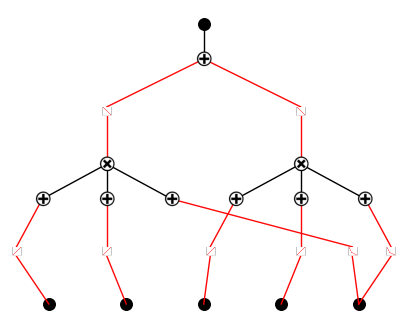

In [70]:
# Определение символьных переменных и формулуы
x, v, k, c, m = symbols('x, v, k, c, m')
expr = -(k/m)*x-(c/m)*v

# Компиляция
model_kan = kanpiler(input_variables=[c, v, k, x, m], expr=expr)

model_kan.get_act(dataset)
model_kan.plot()

| train_loss: 5.84e-03 | test_loss: 5.62e-03 | reg: 0.00e+00 | : 100%|█| 1200/1200 [01:41<00:00, 11.


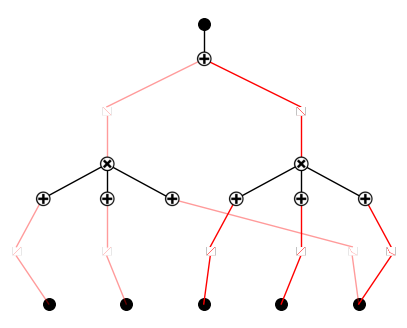

In [71]:
model_kan.fit(dataset, opt="Adam", steps=700, lr=0.01)
model_kan.plot()

In [72]:
lib = ['x']
model_kan.auto_symbolic(lib=lib)
formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ", formula)

skipping (0,0,0) since already symbolic
skipping (0,0,1) since already symbolic
skipping (0,0,2) since already symbolic
skipping (0,0,3) since already symbolic
skipping (0,0,4) since already symbolic
skipping (0,0,5) since already symbolic
skipping (0,1,0) since already symbolic
skipping (0,1,1) since already symbolic
skipping (0,1,2) since already symbolic
skipping (0,1,3) since already symbolic
skipping (0,1,4) since already symbolic
skipping (0,1,5) since already symbolic
skipping (0,2,0) since already symbolic
skipping (0,2,1) since already symbolic
skipping (0,2,2) since already symbolic
skipping (0,2,3) since already symbolic
skipping (0,2,4) since already symbolic
skipping (0,2,5) since already symbolic
skipping (0,3,0) since already symbolic
skipping (0,3,1) since already symbolic
skipping (0,3,2) since already symbolic
skipping (0,3,3) since already symbolic
skipping (0,3,4) since already symbolic
skipping (0,3,5) since already symbolic
skipping (0,4,0) since already symbolic


KAN

In [73]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:
      for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
        for v0 in [0.0, 0.5, 1.0]:
          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 10, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v
          for i in range(len(x)):
            all_data.append([x[i], v[i], k, c, 1/m, a_clean[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

# Извлекаем исходные столбцы
x = all_data[:, 0]
v = all_data[:, 1]
k = all_data[:, 2]
c = all_data[:, 3]
inv_m = all_data[:, 4]
a = all_data[:, 5]

# Вычисляем производные признаки
k_over_m = k * inv_m                # k/m
c_over_m = c * inv_m                # c/m
k_x_over_m = k * x * inv_m          # k*x/m
c_v_over_m = c * v * inv_m          # c*v/m

# Формируем расширенный массив входов (9 признаков)
X_ext = np.column_stack([
    x, v, k, c, inv_m,              # исходные пять
    k_over_m, c_over_m,             # отношения
    k_x_over_m, c_v_over_m          # произведения
])
y = a

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_ext, y, test_size=0.2, random_state=42
)

# Масштабируем все входные признаки
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Подвыборки для ускорения обучения (можно варьировать размер)
n_train = 10000
indices_train = np.random.choice(len(X_train_scaled), size=n_train, replace=False)
X_train_sub = X_train_scaled[indices_train]
y_train_sub = y_train[indices_train]

n_test = 3000
indices_test = np.random.choice(len(X_test_scaled), size=n_test, replace=False)
X_test_sub = X_test_scaled[indices_test]
y_test_sub = y_test[indices_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")
print(f"Размерность входа: {X_train_t.shape[1]}")  # должно быть 9

Всего точек: 40500
train: 10000 примеров, test: 3000 примеров
Размерность входа: 9


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.18e-02 | test_loss: 7.93e-02 | reg: 1.44e+01 | : 100%|█| 700/700 [00:32<00:00, 21.37


saving model version 0.1


| train_loss: 1.21e-03 | test_loss: 5.01e-03 | reg: 8.11e+00 | : 100%|█| 500/500 [03:49<00:00,  2.18


saving model version 0.2


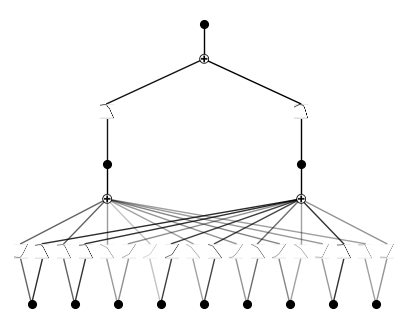

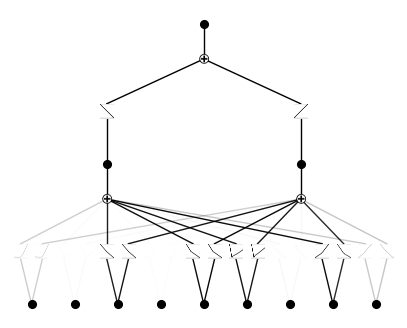

In [74]:
model = KAN(width=[9, 2, 1], grid=3, k=1, seed=42, device=device)
model(dataset['train_input']);
model.plot()

model.fit(dataset, opt="Adam", steps=500, lr=0.01)
model.fit(dataset, opt="LBFGS", steps=200, lr=0.5, lamb=0.0, lamb_entropy=1e-6)
model.plot()

saving model version 0.3


| train_loss: 1.05e-03 | test_loss: 5.17e-03 | reg: 1.49e+01 | : 100%|█| 100/100 [01:15<00:00,  1.32


saving model version 0.4


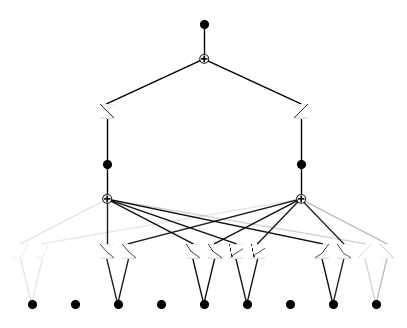

In [75]:
model = model.prune()
model.fit(dataset, opt="LBFGS", steps=100, update_grid=False)
model.plot()

In [76]:
lib = ['x']
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ", formula)

fixing (0,0,0) with x, r2=0.7862647175788879, c=1
fixing (0,0,1) with x, r2=0.7574242949485779, c=1
fixing (0,1,0) with 0
fixing (0,1,1) with 0
fixing (0,2,0) with x, r2=0.9910963773727417, c=1
fixing (0,2,1) with x, r2=0.9906435012817383, c=1
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (0,4,0) with x, r2=0.9583736658096313, c=1
fixing (0,4,1) with x, r2=0.9584865570068359, c=1
fixing (0,5,0) with x, r2=2.110966761392774e-06, c=1
fixing (0,5,1) with x, r2=0.002728739520534873, c=1
fixing (0,6,0) with 0
fixing (0,6,1) with 0
fixing (0,7,0) with x, r2=0.9577198624610901, c=1
fixing (0,7,1) with x, r2=0.9167923927307129, c=1
fixing (0,8,0) with x, r2=0.9486380815505981, c=1
fixing (0,8,1) with x, r2=0.9788928031921387, c=1
fixing (1,0,0) with x, r2=0.9999962449073792, c=1
fixing (1,1,0) with x, r2=0.9999924898147583, c=1
saving model version 0.5
Символьная формула KAN:  -0.0019*x_1 - 0.0283*x_3 - 0.0356*x_5 + 0.0453*x_6 - 1.6341*x_8 - 0.2374*x_9 - 0.0491
